In [2]:
import requests
import pandas as pd

url = "https://api.github.com/search/repositories?q=language:python&sort=stars&order=desc&per_page=100"
response = requests.get(url)
data = response.json()

repos = data['items']
df = pd.DataFrame(repos)

df_clean = pd.DataFrame({
    'repo_id': df['id'],
    'name': df['name'],
    'full_name': df['full_name'],
    'owner_username': df['owner'].apply(lambda x: x['login'] if isinstance(x, dict) else None),
    'stars_count': df['stargazers_count'],
    'forks_count': df['forks_count'],
    'open_issues_count': df['open_issues_count'],
    'language': df['language'],
    'license_name': df['license'].apply(lambda x: x['name'] if isinstance(x, dict) and x is not None else 'No License'),
    'created_at': pd.to_datetime(df['created_at']),
    'updated_at': pd.to_datetime(df['updated_at'])
})

df_clean.drop_duplicates(subset=['repo_id'], inplace=True)
df_clean['language'].fillna('Unknown', inplace=True)

df_clean.to_csv('github_projects.csv', index=False)

/tmp/ipykernel_716/3628038702.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['language'].fillna('Unknown', inplace=True)


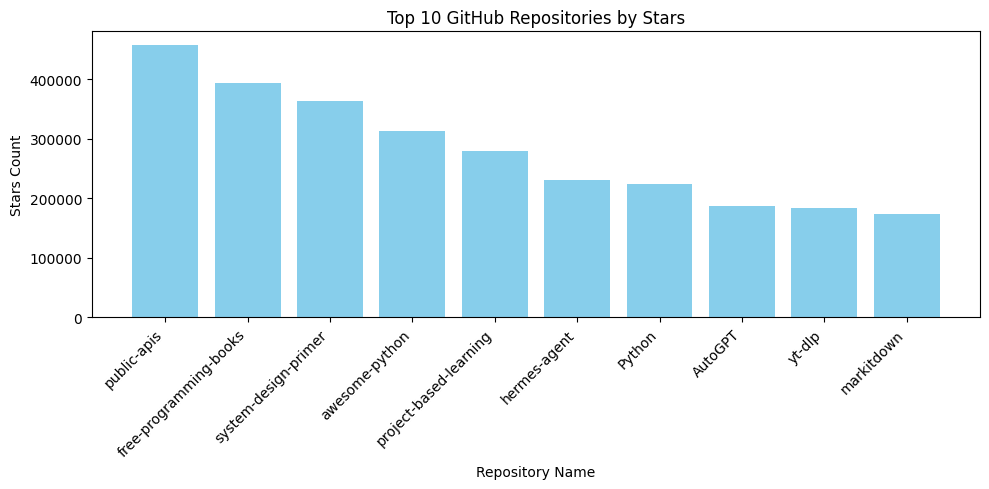

In [3]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('github_projects.csv')

conn = sqlite3.connect('github_projects.db')
df.to_sql('Repositories', conn, if_exists='replace', index=False)

query_filtered = """
SELECT name, stars_count, forks_count
FROM Repositories
WHERE stars_count > 50000 AND forks_count > 10000;
"""
top_repos = pd.read_sql_query(query_filtered, conn)

query_grouped = """
SELECT license_name, COUNT(*) as repo_count, AVG(stars_count) as avg_stars
FROM Repositories
GROUP BY license_name
HAVING repo_count > 1
ORDER BY repo_count DESC;
"""
license_summary = pd.read_sql_query(query_grouped, conn)

plt.figure(figsize=(10, 5))
plt.bar(top_repos['name'].head(10), top_repos['stars_count'].head(10), color='skyblue')
plt.title('Top 10 GitHub Repositories by Stars')
plt.xlabel('Repository Name')
plt.ylabel('Stars Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

conn.close()